In [1]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

## **Analyze graduate salaries.**

Explore the data.

In [2]:

# load dataset
url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/graduates.csv"

graduates_df = pd.read_csv(url)

# display basic information
print(graduates_df.shape)
print("\nColumns:")
print(graduates_df.columns)

# display first rows
graduates_df.head()

(173, 5)

Columns:
Index(['Major', 'Discipline', 'Total', 'Unemployment_rate', 'Median_salary'], dtype='object')


,Major,Discipline,Total,Unemployment_rate,Median_salary
0,GENERAL AGRICULTURE,Agriculture & Natural Resources,128148,0.026147,50000
1,AGRICULTURE PRODUCTION AND MANAGEMENT,Agriculture & Natural Resources,95326,0.028636,54000
2,AGRICULTURAL ECONOMICS,Agriculture & Natural Resources,33955,0.030248,63000
3,ANIMAL SCIENCES,Agriculture & Natural Resources,103549,0.042679,46000
4,FOOD SCIENCE,Agriculture & Natural Resources,24280,0.049188,62000


 **Initial Observations**

 1. The dataset measures current median salary, not long-term career trajectory or total lifetime earnings.

 2. There are a limited number of variables so direct causal links will not be feasible.

 3. There is potential overlap / redundancy between two categorical variables: discipline and major. This can cause multicollinearity and interpretability issues.  

 4. Think carefully about the following: model purpose, interpretability, parameter explosion, sample size

 5. The data is limited but sufficient for a regression analysis.  There are only 173 rows.

In [3]:
# summary statistics for numerical variables
graduates_df.describe()

,Total,Unemployment_rate,Median_salary
count,1.730000e+02,173.000000,173.000000
mean,2.302566e+05,0.057355,56816.184971
std,4.220685e+05,0.019177,14706.226865
min,2.396000e+03,0.000000,35000.000000
25%,2.428000e+04,0.046261,46000.000000
50%,7.579100e+04,0.054719,53000.000000
75%,2.057630e+05,0.069043,65000.000000
max,3.123510e+06,0.156147,125000.000000


In [4]:
# check for missing values
graduates_df.isnull().sum()

,0
Major,0
Discipline,0
Total,0
Unemployment_rate,0
Median_salary,0


In [5]:
# inspect categorical variables
print("Number of unique majors:", graduates_df["Major"].nunique())
print("Number of unique disciplines:", graduates_df["Discipline"].nunique())

print("\nDisciplines:")
print(graduates_df["Discipline"].unique())

Number of unique majors: 173
Number of unique disciplines: 16

Disciplines:
['Agriculture & Natural Resources' 'Biology & Life Science' 'Engineering'
 'Humanities & Liberal Arts' 'Communications & Journalism'
 'Computers & Mathematics' 'Industrial Arts & Consumer Services'
 'Education' 'Law & Public Policy' 'Interdisciplinary' 'Health'
 'Social Science' 'Physical Sciences' 'Psychology & Social Work' 'Arts'
 'Business']


In [6]:
# median salary summary by discipline
discipline_salary_summary = (
    graduates_df
    .groupby("Discipline")["Median_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

discipline_salary_summary

,count,mean,median,min,max
Discipline,,,,,
Engineering,29,77758.620690,75000.0,60000,125000
Computers & Mathematics,11,66272.727273,66000.0,50000,92000
Physical Sciences,10,62400.000000,60000.0,55000,80000
Business,13,60615.384615,60000.0,49000,72000
Health,12,56458.333333,50000.0,42000,106000
Agriculture & Natural Resources,10,55000.000000,53000.0,46000,63000
Social Science,9,53222.222222,52000.0,45000,69000
Law & Public Policy,5,52800.000000,50000.0,48000,60000
Industrial Arts & Consumer Services,7,52642.857143,48000.0,40000,67000


**Data Summary Observations**
1. My suspicions about the "major" and "discipline" categories was correct.  There are 173 majors and only 173 rows.  Do not dummy encode "major" as doing so would essentially create a near-saturated model and result in overparameterization and weak interpretability.  

2. Discipline is likely the better categorical predictor for a baseline OLS model.

3. The discipline means are clearly separated. The signal is very apparent even before doing any modeling.

4. Small group sizes for interdisciplinary, communications, law & public policy. This means variance may be misleading and coefficients may become noisy.

**possible mediator pathway**

1. unemployment_rate could be an intermediary variable between discipline and salary.

2. Discipline → Labor Demand / Unemployment → Salary

We will start with the broader categorical structure first using the "discipline" categorical variable. OLS is the baseline.

**Models**

**Model A: Estimate the total association**


*   Salary ∼ Discipline





**Model B: Estimate the discipline association after accounting for unemployment**

*   Salary ∼ Discipline+Unemployment

**OLS Model Assumptions**

For OLS, we should evaluate assumptions such as:

*   Linearity
*   Independence of errors
*   Homoscedasticity
*   Normality of residuals
*   Multicollinearity
*  Influence/outliers












In [7]:
# fit baseline model for diagnostics
diagnostic_model = smf.ols(
    formula="Median_salary ~ C(Discipline) + Unemployment_rate",
    data=graduates_df
).fit()

In [8]:
# residuals and fitted values
residuals = diagnostic_model.resid
fitted_vals = diagnostic_model.fittedvalues

**Residuals vs Fitted Values**

This plot is primarily checking:

*   linearity
*   homoscedasticity
*   List item
*   structural patterns


Conclusion

*   linearity assumption appears reasonably acceptable
*   mild heteroscedasticity/outlier concerns
*   List item
*   nothing catastrophically wrong visually








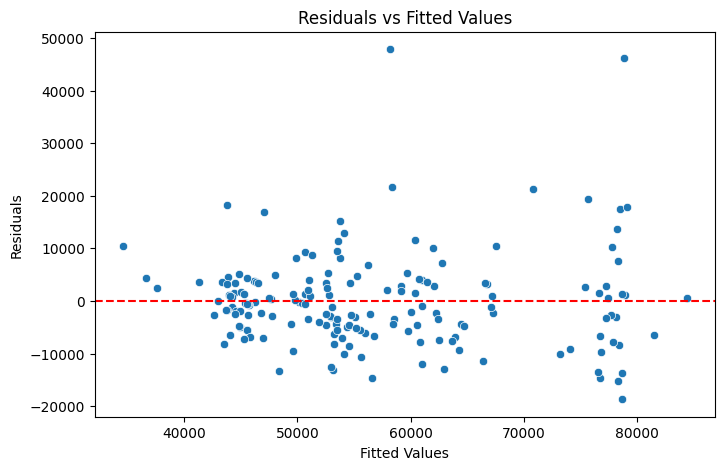

In [9]:
# residuals vs fitted values plot
plt.figure(figsize=(8, 5))

sns.scatterplot(x=fitted_vals, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

**Histogram of Residuals**

We want an approximately bell-shaped residuals.

The histogram is clearly right-skewed, heavy positive tail, and visible extreme residuals.

Conclusion

*   Residual normality assumption is violated to some degree. which already aligns with the high kurtosis from the OLS summary and the subsequent Shapiro-Wilk result.

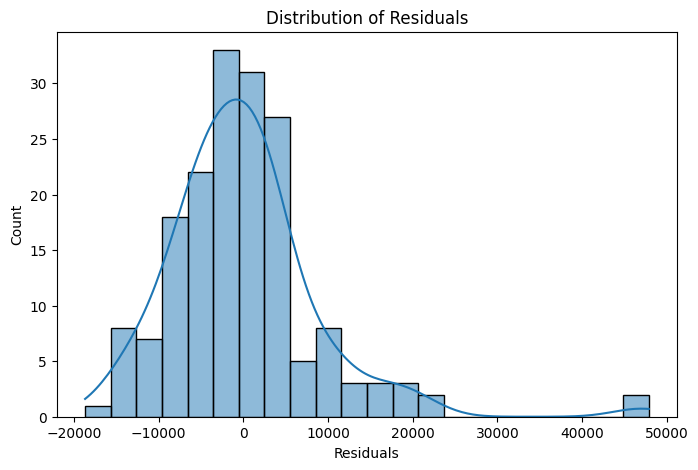

In [10]:
# histogram of residuals
plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.show()

**Q-Q Plot**

We want points closely following the line.

The plot reveals the following:

*   center is reasonably aligned
*   tails deviate substantially
*   especially upper tail


This indicates

*   heavy tails
*   non-normal residual behavior
*   likely influential observations/outliers


Conclusion

Residual normality assumption is not well satisfied, but the middle portion fits reasonably well, which matters.

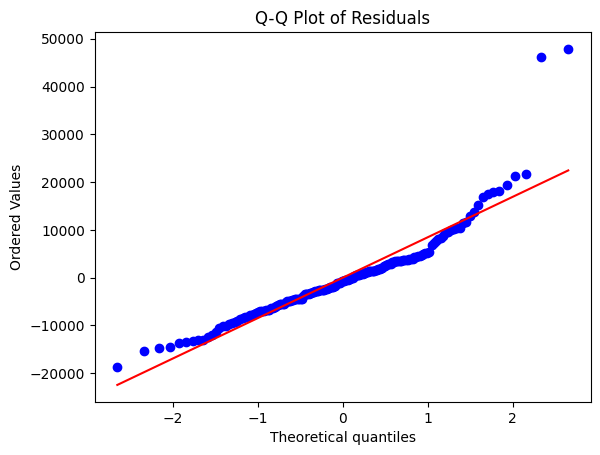

In [11]:
# Q-Q plot for residual normality
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.show()

**Shapiro-Wilk Test**

Null hypothesis:

H(0): Residuals are normally distributed

Model obtained: p≈1.09×10^−10

Conclusion

Reject the null of normal residuals. This statistically confirms what we saw visually.

In [12]:
# shapiro-wilk normality test
shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test")
print("------------------")
print(f"Statistic: {shapiro_test.statistic}")
print(f"P-value: {shapiro_test.pvalue}")

Shapiro-Wilk Test
------------------
Statistic: 0.8775594046463033
P-value: 1.0936195194284833e-10


**Breusch-Pagan Test**

Null hypothesis:

H(0) :constant variance (homoscedasticity)

Model obtained: p≈0.54

Conclusion:
*   We fail to reject homoscedasticity.
*   Despite some visual spread differences, there is not strong statistical evidence of heteroscedasticity.



In [13]:
# breusch-pagan test for homoscedasticity
bp_test = het_breuschpagan(
    residuals,
    diagnostic_model.model.exog
)

bp_labels = [
    "Lagrange multiplier statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print("Breusch-Pagan Test")
print("-------------------")

for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value}")

Breusch-Pagan Test
-------------------
Lagrange multiplier statistic: 14.851472897495004
p-value: 0.5355426544712464
f-value: 0.9156067615901471
f p-value: 0.552633563376955


**Variance Inflation Factor(VIF) Results**

VIF checks multicollinearity.

*   VIF measures how much the variance (uncertainty) of a regression coefficient is inflated because of multicollinearity with other predictors.
*   Conceptually, If a predictor is highly correlated with other predictors, the model struggles to separate their individual effects.
*   This causes unstable coefficients, larger standard errors, AND less reliable inference.


Rules of thumb:
*   VIF < 5 → generally acceptable
*   VIF < 10 → often tolerable


The model VIFs are mostly around 1–3 which is xcellent.

Conclusion
*   There are no meaningful multicollinearity concerns.

In [14]:
# build dataframe for VIF calculation
X = diagnostic_model.model.exog

vif_df = pd.DataFrame()

vif_df["Variable"] = diagnostic_model.model.exog_names

vif_df["VIF"] = [
    variance_inflation_factor(X, i)
    for i in range(X.shape[1])
]

vif_df

,Variable,VIF
0,Intercept,24.189241
1,C(Discipline)[T.Arts],2.164464
2,C(Discipline)[T.Biology & Life Science],2.240951
3,C(Discipline)[T.Business],2.195302
4,C(Discipline)[T.Communications & Journalism],1.454443
5,C(Discipline)[T.Computers & Mathematics],2.069886
6,C(Discipline)[T.Education],2.378644
7,C(Discipline)[T.Engineering],3.321354
8,C(Discipline)[T.Health],2.063978
9,C(Discipline)[T.Humanities & Liberal Arts],2.593893


**Cook’s Distance**

The biggest red flag is that blue huge spike which indicates at least one highly influential observation.

This spike is very likely the 125k engineering salary point or another extreme discipline value. This observation may heavily influence coefficients, significance, and fitted structure.

Conclusion

*   There is likely at least one influential outlier observation that should be investigated further.  This is probably the most important diagnostic issue in the model.

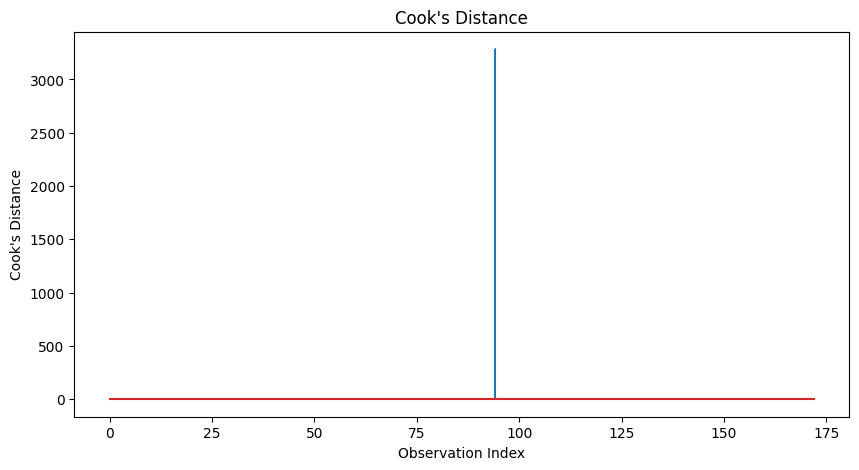

In [15]:
# influence diagnostics
influence = diagnostic_model.get_influence()

cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))

plt.stem(
    np.arange(len(cooks_d)),
    cooks_d,
    markerfmt=","
)

plt.title("Cook's Distance")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")

plt.show()

**OLS Assumptions Summary**

In [16]:
# baseline OLS model
model_1 = smf.ols(
    formula="Median_salary ~ C(Discipline)",
    data=graduates_df
).fit()

# display results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_salary   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     16.31
Date:                Wed, 06 May 2026   Prob (F-statistic):           6.02e-25
Time:                        20:52:38   Log-Likelihood:                -1823.8
No. Observations:                 173   AIC:                             3680.
Df Residuals:                     157   BIC:                             3730.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

**Note**:

1. Statsmodels automatically dropped one discipline as the baseline/reference group.

2. dummy-coded categorical coefficients are interpreted relative to the reference category.

3. Agriculture & Natural Resources is the baseline and is missing in the set of predictors.

*   For example, we can see that engineering majors are associated with approximately $22,760 higher median salary than "Agriculture & Natural Resources" majors on average.


## Baseline OLS Regression Summary

The baseline OLS regression model examined whether median graduate salaries differ systematically across academic disciplines. Using discipline as the sole predictor, the model explained approximately 61% of the observed variation in median salaries \((R^2 = 0.609)\), indicating that discipline is strongly associated with graduate earnings outcomes. The overall F-test was highly statistically significant, suggesting that at least some disciplines differ meaningfully in average salary levels.

Several disciplines showed statistically significant negative associations relative to the reference group, including Arts, Education, and Psychology & Social Work. These results suggest that graduates in these disciplines tend to have lower median salaries on average compared to graduates in Agriculture & Natural Resources. However, caution is warranted when interpreting these findings causally because the dataset is observational and lacks many important variables that likely influence salary outcomes, such as geographic location, graduate degrees, school prestige, work experience, labor market conditions, and student aptitude.

Overall, the analysis provides strong evidence that academic discipline is associated with meaningful differences in graduate salary outcomes, though the model should primarily be interpreted as descriptive and explanatory rather than causal.

Now, we need to know the following:

*   Does unemployment rate explain additional variation in salary beyond discipline alone?




**Model B: Estimate the discipline association after accounting for unemployment**


Does unemployment rate explain additional variation in salary beyond discipline alone?

In [17]:
# extended OLS model with unemployment rate
model_2 = smf.ols(
    formula="Median_salary ~ C(Discipline) + Unemployment_rate",
    data=graduates_df
).fit()

# display results
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_salary   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     16.38
Date:                Wed, 06 May 2026   Prob (F-statistic):           7.89e-26
Time:                        20:52:38   Log-Likelihood:                -1819.8
No. Observations:                 173   AIC:                             3674.
Df Residuals:                     156   BIC:                             3727.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


**Does unemployment rate explain additional variation in salary beyond discipline alone?**


1. Yes, the unemployment rate does in fact explain additional variation in salary.  Now the discipline coefficients mean the following:

    *   salary differences between disciplines AFTER accounting for unemployment rate.

2. Since unemployment rate is stored as a proportion, a 0.01 increase = 1 percentage point increase.  So here is the interpretation:

    *   A 1 percentage point increase in unemployment rate is associated with approximately $1,300 lower median salary, holding discipline constant.









**The updated model also resulted in some interesting shifts**.  

For example:

*   Physical Sciences became statistically significant
*   Business moved closer to significance
*   Arts lost significance

This shows how adding predictors can redistribute explained variance.

**Model B Summary**

In the extended OLS model, unemployment rate was added alongside discipline to examine whether labor market conditions provide additional explanatory power for median graduate salaries. The updated model improved overall fit slightly (R
2
=0.627), suggesting that unemployment contributes meaningful information beyond discipline alone. The unemployment rate coefficient was negative and statistically significant, indicating that higher unemployment rates are associated with lower median salaries after accounting for discipline. Specifically, a one percentage point increase in unemployment rate was associated with an estimated decrease of approximately $1,300 in median salary. Additionally, several discipline coefficients changed in magnitude and significance after unemployment was included, which is consistent with the possibility that unemployment partially overlaps with or helps explain some of the salary differences observed across disciplines.